# Risk parity vs equal weight vs market-cap weight

Splitting money evenly isn't the same as splitting risk evenly. Put a third each into
gold, bitcoin and altcoins and the portfolio moves almost entirely with crypto: gold's
share of the money is 33%, its share of the risk is a few percent. Market-cap weighting
goes the other way and is mostly gold, because gold is worth far more than all of
crypto combined. Risk parity sizes each class so each one contributes the same share of
the portfolio's variance.

The price data has no stocks or bonds, so the three asset classes here are gold
(XAUT, a token backed by one troy ounce of gold each), bitcoin (WBTC) and an altcoin
sleeve of five large alts. The notebook measures how much each class moves on its own
and together, shows capital against risk for each scheme, backtests all three with
monthly rebalancing and fees, checks the risk-parity settings and other altcoin
sleeves, and renders a video.

In [13]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from algo_trading.backtest import backtest as bt, data, plots
from algo_trading.backtest.animate import risk_contributions
from algo_trading.backtest.config import FEE_BPS, PROJECT_ROOT, PortfolioConfig

plots.apply_theme()

# The active dataset in config.yaml has no gold, so read the `historical` one directly.
HIST = PROJECT_ROOT / ".data" / "historical_data.csv"
CLASSES = {"Gold": ["xaut"],
           "Bitcoin": ["wbtc"],
           "Altcoins": ["xrp", "bnb", "link", "aave", "uni"]}   # split evenly inside the sleeve
TOKENS = [t for toks in CLASSES.values() for t in toks]
TOKEN_CLASS = {t: c for c, toks in CLASSES.items() for t in toks}

# Rough units outstanding, held fixed, so market cap = units x price. Not in the dataset:
# gold is the ~216,000 tonnes ever mined (1 XAUT = 1 troy oz); the coins are approximate
# circulating supply over 2024-26. Only the order of magnitude matters here.
SUPPLY = pd.Series({"xaut": 216_000 * 32_150.7, "wbtc": 19.8e6, "xrp": 58e9, "bnb": 143e6,
                    "link": 650e6, "aave": 15.2e6, "uni": 620e6})

LOOKBACK = 90                  # days of returns behind each covariance estimate
MONTH = 30                     # rebalance every 30 days
WARMUP = LOOKBACK + 1          # trades use the prior bar's target: the first full estimate
FEE = FEE_BPS                  # 0.2% per fill
INITIAL = 10_000
SCHEMES = ["market cap", "equal weight", "risk parity"]
CLASS_COLORS = [plots.color(i) for i in (4, 1, 0)]
COLORS = [plots.color(i) for i in (2, 3, 0)]           # one per scheme

## Data

In [14]:
raw = data.load_bars("1d", TOKENS, path=HIST, fmt="long")
panel = data.daily_panel(TOKENS, raw=raw)
close = panel.close[TOKENS].dropna()            # start once every coin has a price
rets = close.pct_change().iloc[1:]
# class returns: the altcoin sleeve is its five coins in equal parts
R = pd.DataFrame({c: rets[toks].mean(axis=1) for c, toks in CLASSES.items()})
print(panel.describe())
print(f"{close.index[0]:%Y-%m-%d} -> {close.index[-1]:%Y-%m-%d}, "
      f"trading from {close.index[WARMUP]:%Y-%m-%d}")

854 1d bars x 7 tokens  2024-05-26 00:00:00+00:00 -> 2026-09-26 00:00:00+00:00
2024-08-01 -> 2026-09-26, trading from 2024-10-31


## How much each class moves

,total_ret,vol,max_dd
Gold,+75%,23%,-28%
Bitcoin,+30%,46%,-53%
Altcoins,+87%,71%,-69%


correlation of daily returns


,Gold,Bitcoin,Altcoins
Gold,1.00,0.17,0.12
Bitcoin,0.17,1.00,0.79
Altcoins,0.12,0.79,1.00


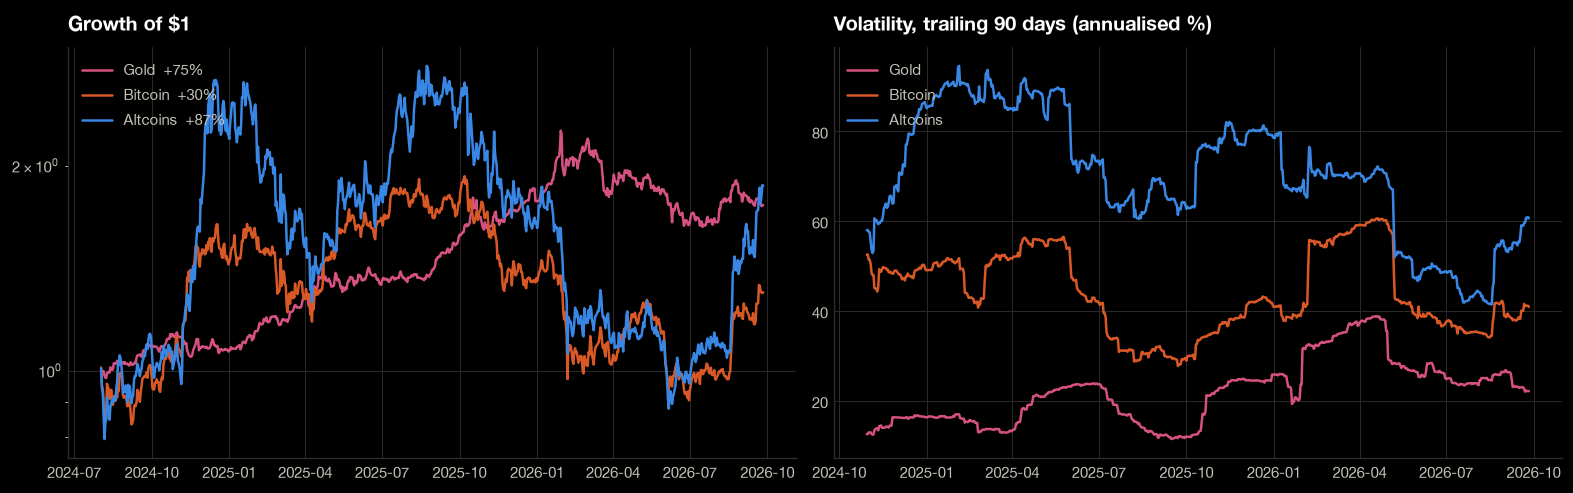

In [15]:
growth = (1 + R).cumprod()
summary = pd.DataFrame({"total_ret": growth.iloc[-1] - 1,
                        "vol": R.std() * np.sqrt(panel.bars_per_year),
                        "max_dd": (growth / growth.cummax() - 1).min()})
display(bt.fmt_table(summary, {"total_ret": "{:+.0%}", "vol": "{:.0%}", "max_dd": "{:.0%}"}))
print("correlation of daily returns")
display(R.corr().round(2))

fig, axes = plt.subplots(1, 2, figsize=(13, 4), layout="constrained")
for c, col in zip(CLASSES, CLASS_COLORS):
    axes[0].plot(growth[c], color=col, lw=1.5, label=f"{c}  {growth[c].iloc[-1] - 1:+.0%}")
    axes[1].plot(R[c].rolling(LOOKBACK).std() * np.sqrt(panel.bars_per_year) * 100,
                 color=col, lw=1.5, label=c)
axes[0].set_yscale("log")
axes[0].set_title("Growth of $1")
axes[0].legend(loc="upper left")
axes[1].set_title(f"Volatility, trailing {LOOKBACK} days (annualised %)")
axes[1].legend(loc="upper left")
plt.show()

## Capital vs risk

A position's risk contribution is its weight times its covariance with the whole
portfolio, $w_i (\Sigma w)_i$, which sums across positions to the portfolio's variance.
Divided by that variance, it is the share of the portfolio's moves the position is
responsible for. Risk parity (equal risk contribution) solves for the weights that give
every class the same share.

This section uses the covariance of the whole period, so the risk-parity weights here
look ahead; the backtest below only ever uses the trailing 90 days.

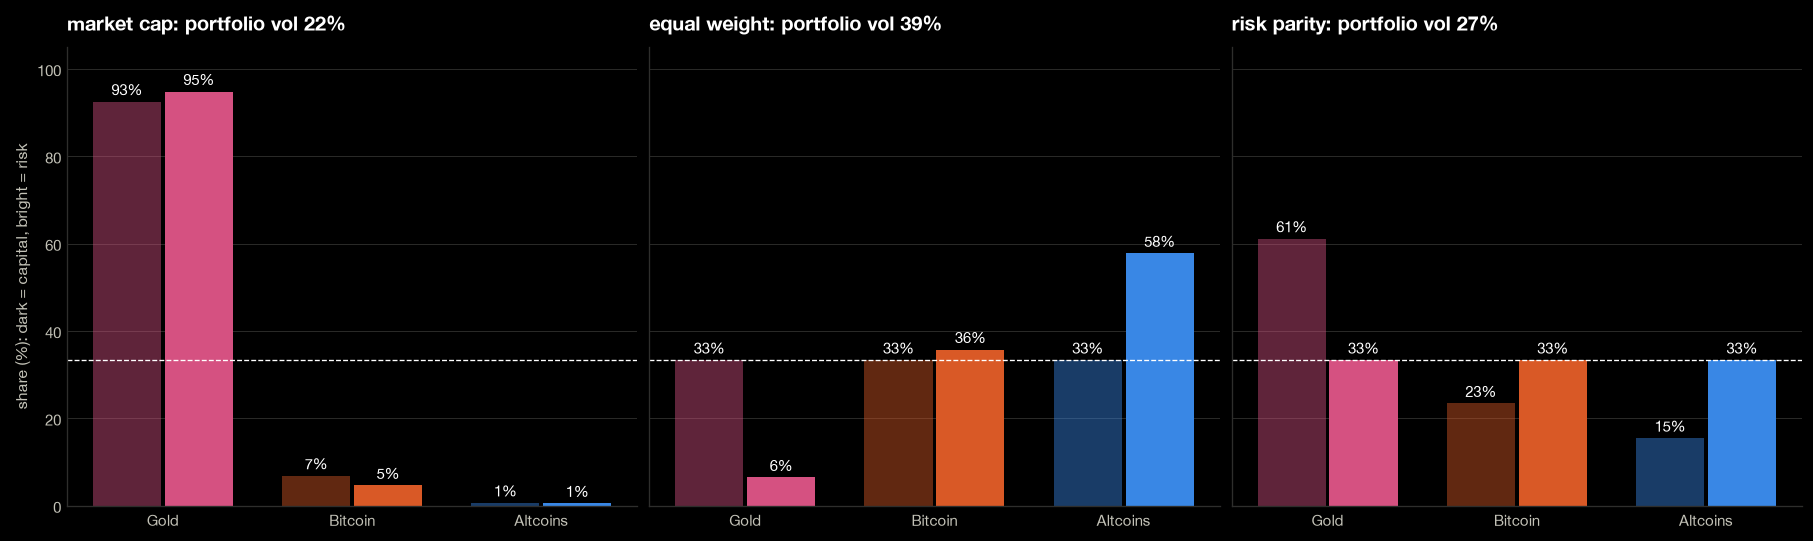

market cap        equal weight        risk parity       
            capital   risk      capital   risk     capital   risk
Gold          92.5%  94.8%        33.3%   6.5%       61.1%  33.3%
Bitcoin        6.9%   4.6%        33.3%  35.8%       23.4%  33.3%
Altcoins       0.6%   0.5%        33.3%  57.8%       15.5%  33.3%

In [16]:
def erc(cov: np.ndarray, sweeps: int = 200, tol: float = 1e-10) -> np.ndarray:
    """Equal-risk-contribution weights, by cyclical coordinate descent.

    Each step solves  cov_ii w_i^2 + w_i sum_{j!=i} cov_ij w_j = 1/n  for w_i, which sets
    asset i's risk contribution to 1/n of the unnormalised total; the result is rescaled
    to sum to 1, which leaves the contributions equal."""
    cov = np.asarray(cov, float)
    n = len(cov)
    w = 1 / np.sqrt(np.diag(cov))
    for _ in range(sweeps):
        before = w.copy()
        for i in range(n):
            c = cov[i] @ w - cov[i, i] * w[i]
            w[i] = (-c + np.sqrt(c * c + 4 * cov[i, i] / n)) / (2 * cov[i, i])
        if np.abs(w - before).max() < tol * w.max():
            break
    return w / w.sum()


def by_class(w_tok: pd.DataFrame | pd.Series) -> pd.DataFrame | pd.Series:
    """Token weights summed into class weights."""
    return w_tok.T.groupby(TOKEN_CLASS).sum().T[list(CLASSES)]


cov_full = R.cov() * panel.bars_per_year
mcap = close * SUPPLY
cap_share = mcap.div(mcap.sum(axis=1), axis=0)
static = {"market cap": by_class(cap_share.iloc[WARMUP]),
          "equal weight": pd.Series(1 / len(CLASSES), index=list(CLASSES)),
          "risk parity": pd.Series(erc(cov_full), index=list(CLASSES))}
split = pd.concat({k: pd.DataFrame({"capital": w, "risk": risk_contributions(w, cov_full)})
                   for k, w in static.items()}, axis=1)
vols = {k: np.sqrt(w @ cov_full @ w) for k, w in static.items()}

fig, axes = plt.subplots(1, 3, figsize=(15, 4.4), layout="constrained", sharey=True)
x = np.arange(len(CLASSES))
for ax, k in zip(axes, static):
    for j, (part, alpha) in enumerate((("capital", 0.45), ("risk", 1.0))):
        vals = split[(k, part)] * 100
        bars = ax.bar(x + (j - 0.5) * 0.38, vals, width=0.36, color=CLASS_COLORS, alpha=alpha)
        ax.bar_label(bars, fmt="%.0f%%", padding=2, fontsize=9)
    ax.axhline(100 / len(CLASSES), color=plt.rcParams["text.color"], lw=0.8, ls="--")
    ax.set_xticks(x, list(CLASSES))
    ax.set_title(f"{k}: portfolio vol {vols[k]:.0%}")
    ax.grid(axis="x", visible=False)
axes[0].set_ylabel("share (%): dark = capital, bright = risk")
axes[0].set_ylim(0, 105)
plt.show()

bt.fmt_table(split, {c: "{:.1%}" for c in split.columns})

## Backtest

Each month the risk-parity target is re-solved from the trailing 90 days of class
returns, and equal weight is reset to a third each; both then trade back to target
(every coin, whole book). Market-cap weight never needs rebalancing: bought at the
start, it drifts with prices exactly as the market caps do (with supply held fixed).
Inside the altcoin sleeve the five coins are equal parts of the sleeve's weight, except
under market-cap weighting, where they are weighted by their own caps.

In [17]:
def to_tokens(cw: pd.DataFrame) -> pd.DataFrame:
    """Spread class weights evenly over each class's coins."""
    return pd.DataFrame({t: cw[c] / len(CLASSES[c]) for t, c in TOKEN_CLASS.items()})[TOKENS]


def rolling_erc(returns: pd.DataFrame, lookback: int) -> pd.DataFrame:
    """Risk-parity class weights from the trailing `lookback` days, bar by bar (NaN before)."""
    out = pd.DataFrame(np.nan, index=close.index, columns=returns.columns)
    for i in range(lookback, len(close)):
        window = returns.loc[:close.index[i]].iloc[-lookback:]   # returns up to this close
        out.iloc[i] = erc(window.cov().to_numpy())
    return out


def run(w: pd.DataFrame, cfg: PortfolioConfig, px: pd.DataFrame = close,
        warmup: int = WARMUP) -> dict:
    return bt.simulate(px, w.fillna(0.0), cfg, fee_bps=FEE, initial=INITIAL, warmup=warmup)


REBAL = PortfolioConfig(check_bars=MONTH, band=0.0, band_all=True, min_trade_frac=0.0)
HOLD = PortfolioConfig(rebalance=False, check_bars=1, band=0.0, min_trade_frac=0.0)

rp_class = rolling_erc(R, LOOKBACK)
targets = {"market cap": cap_share,
           "equal weight": to_tokens(pd.DataFrame(1 / len(CLASSES), index=close.index,
                                                  columns=list(CLASSES))),
           "risk parity": to_tokens(rp_class)}
configs = {"market cap": HOLD, "equal weight": REBAL, "risk parity": REBAL}
runs = {k: run(targets[k], configs[k]) for k in SCHEMES}
held = {k: by_class(bt.held_weights(runs[k], close)) for k in SCHEMES}


def risk_share(w: pd.DataFrame, lookback: int = LOOKBACK) -> pd.DataFrame:
    """Each class's share of risk for the weights actually held, using the trailing
    covariance at each bar."""
    out = pd.DataFrame(np.nan, index=w.index, columns=w.columns)
    for i in range(max(lookback, WARMUP), len(w)):
        cov = R.loc[:w.index[i]].iloc[-lookback:].cov().to_numpy()
        wi = w.iloc[i].to_numpy()
        if wi.sum() > 0:
            out.iloc[i] = risk_contributions(wi, cov)
    return out


risk = {k: risk_share(held[k]) for k in SCHEMES}


def row(k: str) -> dict:
    res = runs[k]
    w, r = held[k].iloc[WARMUP:], risk[k].iloc[WARMUP:]
    return (bt.stats_from_result(res, k, WARMUP, panel.bars_per_year)
            | {"final_$": res["equity"].iloc[-1], "fees_$": res["fees"]}
            | {f"{c.lower()}_cap": w[c].mean() for c in CLASSES}
            | {f"{c.lower()}_risk": r[c].mean() for c in CLASSES})


table = pd.DataFrame([row(k) for k in SCHEMES]).set_index("label")
share_cols = [c for c in table if c.endswith(("_cap", "_risk"))]
bt.fmt_table(table[["final_$", "total_ret", "sharpe", "vol", "max_dd", "n_fills", "fees_$",
                    "turnover", *share_cols]],
             {**bt.PERF_FMT, "final_$": "${:,.0f}", "fees_$": "${:,.0f}",
              **{c: "{:.0%}" for c in share_cols}})

,final_$,total_ret,sharpe,vol,max_dd,n_fills,fees_$,turnover,gold_cap,bitcoin_cap,altcoins_cap,gold_risk,bitcoin_risk,altcoins_risk
label,,,,,,,,,,,,,,
market cap,"$15,086",+51.2%,1.07,23%,-27.8%,7,$20,1.0x,93%,7%,1%,94%,5%,1%
equal weight,"$16,383",+64.2%,0.86,39%,-43.6%,168,$79,3.9x,33%,33%,33%,7%,34%,58%
risk parity,"$16,969",+70.0%,1.19,26%,-30.3%,168,$85,4.3x,62%,23%,15%,35%,32%,33%


`*_cap` is the average share of the money in each class and `*_risk` the average share
of the risk, both measured on what the portfolio actually held (after drift between
rebalances) against the trailing 90-day covariance.

## Capital and risk over time

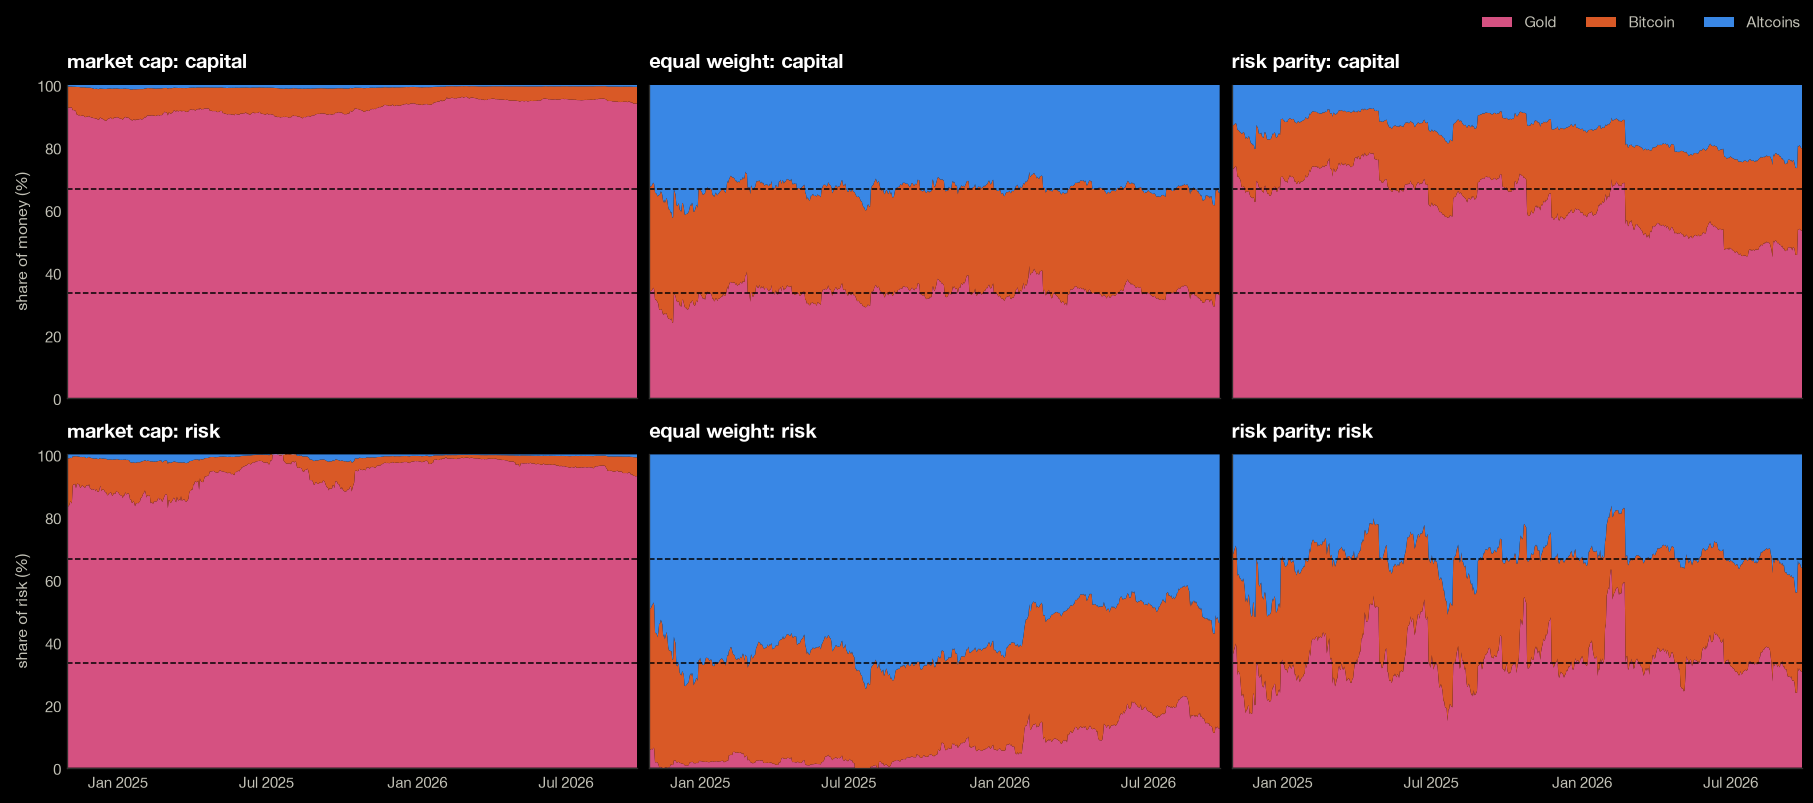

In [18]:
def stack(ax, w: pd.DataFrame, title: str) -> None:
    w = w.iloc[WARMUP:] * 100
    ax.stackplot(w.index, w.T, colors=CLASS_COLORS, labels=list(CLASSES), lw=0)
    for v in (100 / 3, 200 / 3):
        ax.axhline(v, color=plt.rcParams["axes.facecolor"], lw=0.9, ls="--")
    ax.set_ylim(0, 100)
    ax.set_xlim(w.index[0], w.index[-1])
    ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=(1, 7)))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    ax.grid(False)
    ax.set_title(title)


fig, axes = plt.subplots(2, 3, figsize=(15, 6.6), layout="constrained", sharex=True, sharey=True)
for j, k in enumerate(SCHEMES):
    stack(axes[0, j], held[k], f"{k}: capital")
    stack(axes[1, j], risk[k], f"{k}: risk")
axes[0, 0].set_ylabel("share of money (%)")
axes[1, 0].set_ylabel("share of risk (%)")
fig.legend(*axes[0, 0].get_legend_handles_labels(), loc="outside upper right", ncol=3)
plt.show()

## Equity

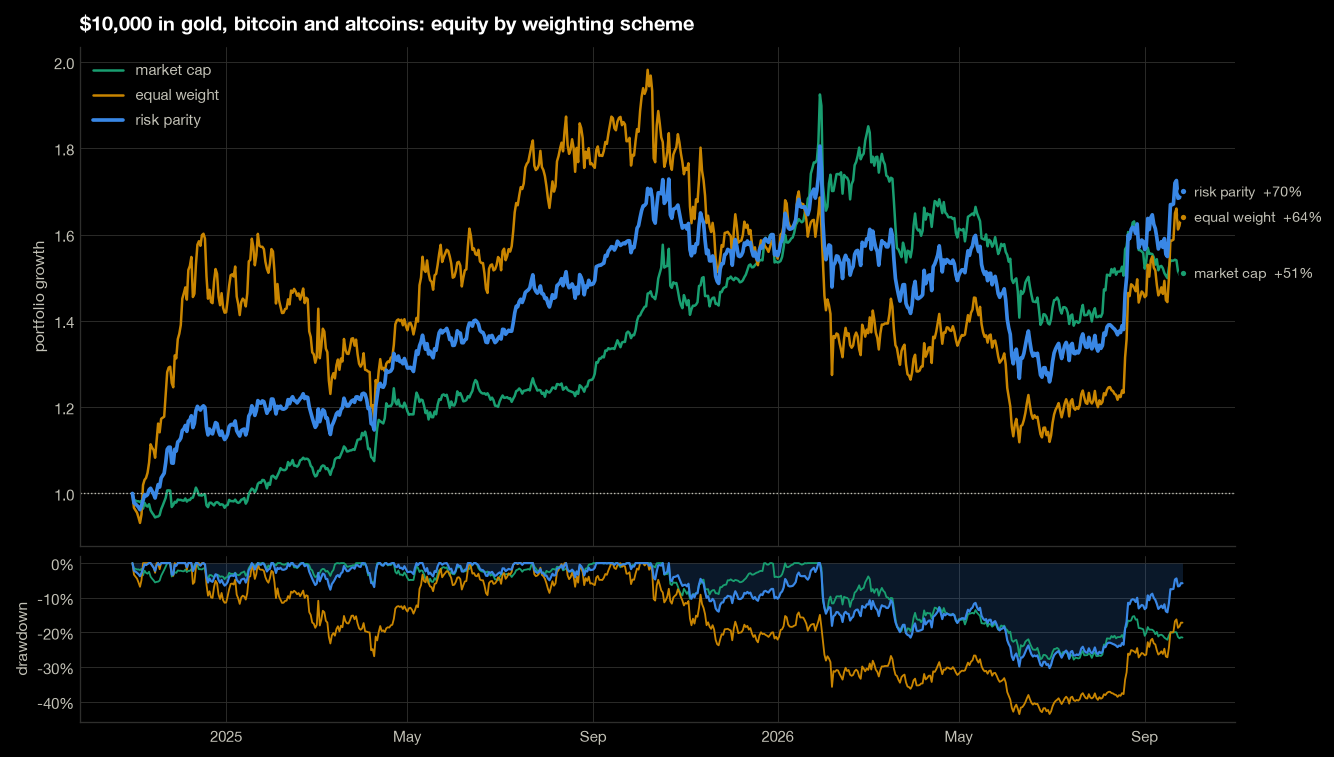

In [19]:
plots.equity_drawdown({k: runs[k]["equity"].iloc[WARMUP:] for k in SCHEMES},
                      f"${INITIAL:,.0f} in gold, bitcoin and altcoins: equity by weighting scheme",
                      colors=COLORS, dd_for="risk parity")
plt.show()

## Risk parity settings

The two choices inside risk parity are how much history the covariance is estimated
from and how often the book is reset. Every cell below starts on the same day (after
the longest lookback), so they are comparable with each other but not with the table
above; equal weight over the same days is the reference.

equal weight, same days: return +9%, Sharpe 0.32, vol 38%, max drawdown -44%


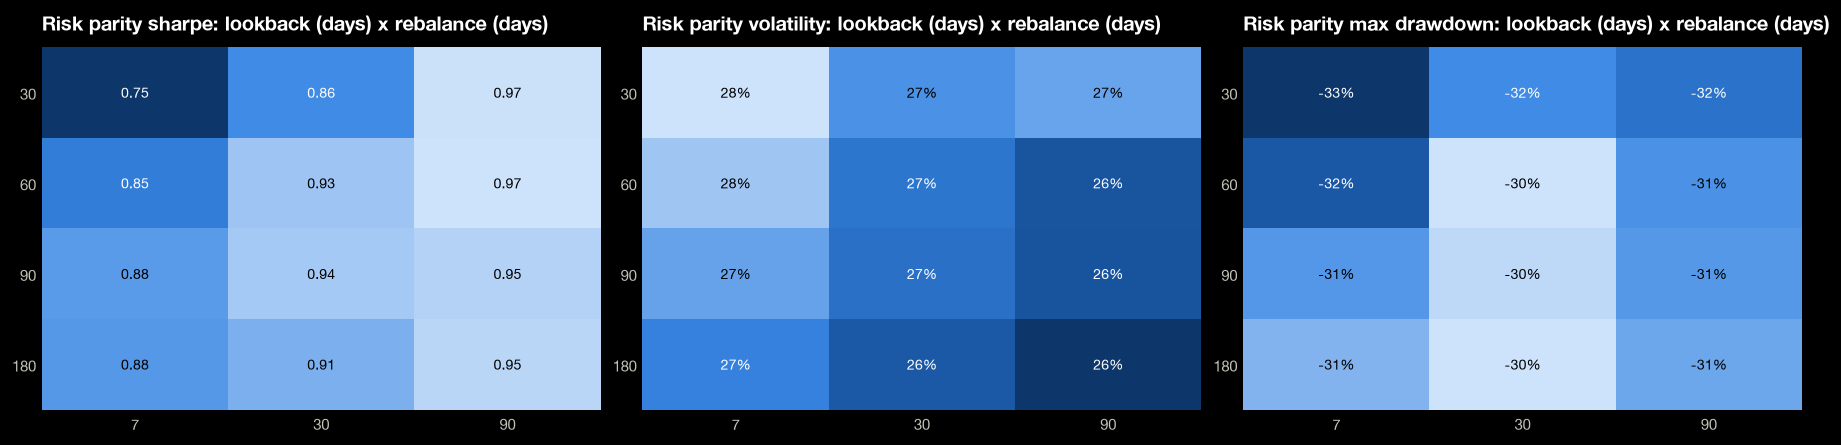

In [20]:
LOOKBACKS = [30, 60, 90, 180]
PERIODS = [7, 30, 90]
W0 = max(LOOKBACKS) + 1

rp_by_lb = {lb: to_tokens(rolling_erc(R, lb)) for lb in LOOKBACKS}
cells = []
for lb in LOOKBACKS:
    for p in PERIODS:
        cfg = PortfolioConfig(check_bars=p, band=0.0, band_all=True, min_trade_frac=0.0)
        res = run(rp_by_lb[lb], cfg, warmup=W0)
        cells.append({"lookback": lb, "period": p, "fees": res["fees"],
                      **{m: v for m, v in bt.stats_from_result(res, "", W0, panel.bars_per_year)
                         .items() if m in ("total_ret", "sharpe", "vol", "max_dd")}})
grid = pd.DataFrame(cells)
ew_ref = bt.stats_from_result(run(targets["equal weight"], REBAL, warmup=W0), "", W0,
                              panel.bars_per_year)
print(f"equal weight, same days: return {ew_ref['total_ret']:+.0%}, Sharpe "
      f"{ew_ref['sharpe']:.2f}, vol {ew_ref['vol']:.0%}, max drawdown {ew_ref['max_dd']:.0%}")

fig, axes = plt.subplots(1, 3, figsize=(15, 3.6), layout="constrained")
for ax, (m, fmt, title) in zip(axes, [("sharpe", "{:.2f}", "Sharpe"),
                                      ("vol", "{:.0%}", "Volatility"),
                                      ("max_dd", "{:.0%}", "Max drawdown")]):
    plots.heatmap(grid.pivot(index="lookback", columns="period", values=m),
                  f"Risk parity {title.lower()}: lookback (days) x rebalance (days)", fmt=fmt,
                  ax=ax)
plt.show()

## Other altcoin sleeves

The five alts above are one choice. Here the altcoin sleeve is drawn at random, 100
times, from every alt in the file with a price on every day of the same window, and
equal weight and risk parity are run on each. Market-cap weight is left out: it needs a
supply figure for every coin, and at any sleeve it is still mostly gold.

In [21]:
N_SLEEVES, SEED = 100, 0

universe = data.load_universe(path=HIST, fmt="long")
every = data.daily_panel(universe, raw=data.load_bars("1d", path=HIST, fmt="long")).close
every = every.reindex(close.index)                     # the same days as above
pool = sorted(t for t in every.columns[every.notna().all()] if t not in ("xaut", "wbtc"))
rng = np.random.default_rng(SEED)
sleeves = [sorted(rng.choice(pool, 5, replace=False)) for _ in range(N_SLEEVES)]
print(f"{len(pool)} alts with a full history: {', '.join(pool)}")

rows = []
for alts in sleeves:
    px = every[["xaut", "wbtc", *alts]]
    r = px.pct_change().iloc[1:]
    rc = pd.DataFrame({"Gold": r.xaut, "Bitcoin": r.wbtc, "Altcoins": r[alts].mean(axis=1)})
    cw = {"equal weight": pd.DataFrame(1 / 3, index=px.index, columns=list(CLASSES)),
          "risk parity": rolling_erc(rc, LOOKBACK)}
    for k, c in cw.items():
        w = pd.DataFrame({"xaut": c.Gold, "wbtc": c.Bitcoin,
                          **{a: c.Altcoins / len(alts) for a in alts}})
        res = run(w, REBAL, px)
        s = bt.stats_from_result(res, k, WARMUP, panel.bars_per_year)
        rows.append({"sleeve": "/".join(alts), "scheme": k, "fees": res["fees"],
                     "gold_risk": risk_contributions(c.iloc[-1].fillna(1 / 3).to_numpy(),
                                                     rc.iloc[-LOOKBACK:].cov().to_numpy())[0],
                     **{m: s[m] for m in ("total_ret", "sharpe", "vol", "max_dd")}})
multi = pd.DataFrame(rows)
by = {k: multi[multi.scheme == k].set_index("sleeve") for k in ("equal weight", "risk parity")}
med = multi.groupby("scheme")[["total_ret", "sharpe", "vol", "max_dd", "fees", "gold_risk"]].median()
med["rp_better"] = [np.nan, (by["risk parity"].sharpe > by["equal weight"].sharpe).mean()]
med["rp_shallower_dd"] = [np.nan, (by["risk parity"].max_dd > by["equal weight"].max_dd).mean()]
print(f"median over {N_SLEEVES} random altcoin sleeves; gold_risk is gold's share of risk "
      "at the last bar")
bt.fmt_table(med, {"total_ret": "{:+.0%}", "sharpe": "{:.2f}", "vol": "{:.0%}",
                   "max_dd": "{:.0%}", "fees": "${:,.0f}", "gold_risk": "{:.0%}",
                   "rp_better": "{:.0%}", "rp_shallower_dd": "{:.0%}"})

13 alts with a full history: aave, bnb, crv, ena, ldo, link, ondo, pepe, spx, trac, uni, wtao, xrp
median over 100 random altcoin sleeves; gold_risk is gold's share of risk at the last bar


,total_ret,sharpe,vol,max_dd,fees,gold_risk,rp_better,rp_shallower_dd
scheme,,,,,,,,
equal weight,+47%,0.68,43%,-44%,$88,11%,—,—
risk parity,+60%,1.06,27%,-29%,$82,33%,100%,100%


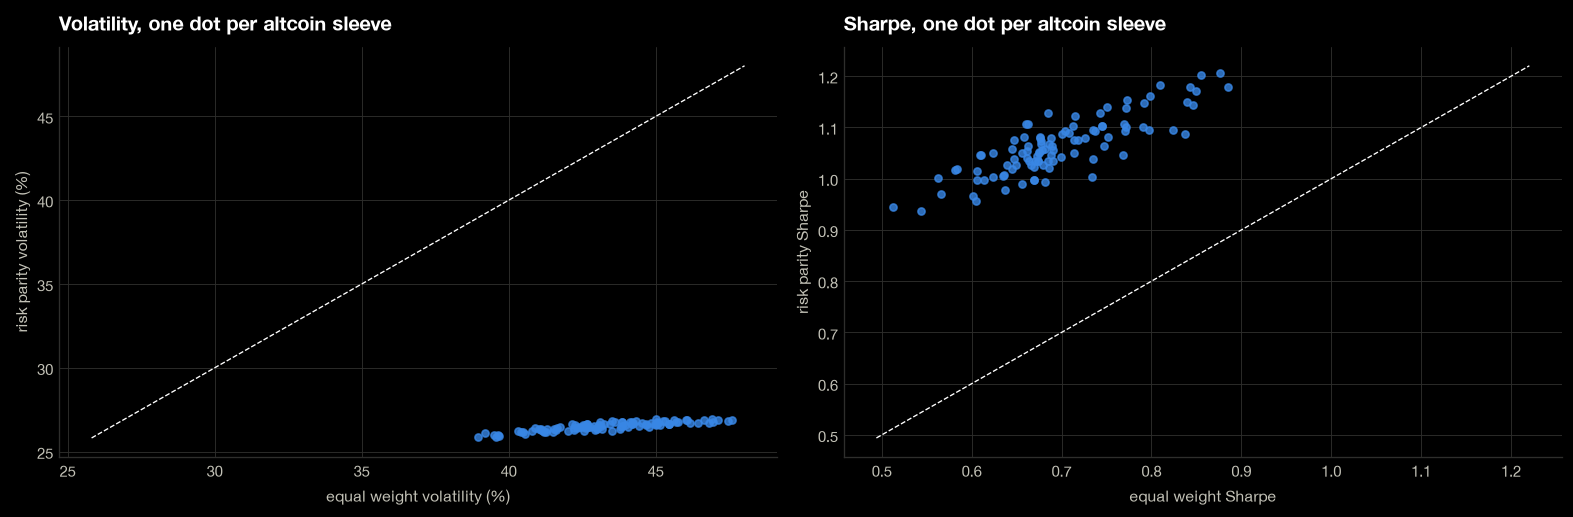

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2), layout="constrained")
for ax, (m, label) in zip(axes, [("vol", "volatility (%)"), ("sharpe", "Sharpe")]):
    ax.scatter(by["equal weight"][m] * (100 if m == "vol" else 1),
               by["risk parity"][m] * (100 if m == "vol" else 1),
               s=18, color=COLORS[2], alpha=0.8)
    lo, hi = ax.get_xlim()[0], ax.get_xlim()[1]
    lo, hi = min(lo, ax.get_ylim()[0]), max(hi, ax.get_ylim()[1])
    ax.plot([lo, hi], [lo, hi], color=plt.rcParams["text.color"], lw=0.8, ls="--")
    ax.set_xlabel(f"equal weight {label}")
    ax.set_ylabel(f"risk parity {label}")
    ax.set_title(f"{label.split(' ')[0].capitalize()}, one dot per altcoin sleeve")
plt.show()

Reading the results: the headline holds everywhere it was tested. At equal weight, gold
is a third of the money and well under a fifth of the risk; bitcoin and the altcoins,
which move together (correlation around 0.8), carry the rest. Risk parity puts roughly
60% in gold to even that out, which cut volatility from about 39% to 26% and the worst
drawdown from about 44% to 30%, for similar fees. It had the higher Sharpe for every
lookback and rebalance period tried and for every random altcoin sleeve.

Two cautions. This was a very good period for gold (+75% at a quarter of bitcoin's
volatility), and risk parity is mostly gold, so part of its edge here is the period, not
the method; in a gold bear market the same weights would lag. And the estimates are
noisy: the risk-share panels show the realised split swinging well away from a third
each between monthly resets. Risk parity is usually run with leverage to bring its
volatility back up to a target; this long-only engine can't, so the comparison here is
at lower risk, not equal risk. Market-cap weight is almost all gold, so it behaves like
holding gold.

## Video: same money, different risk

Two parts, joined: capital and risk side by side, moving from market-cap weight to
equal weight to risk parity (whole-period covariance, as in *Capital vs risk*), then the
three backtests racing, with drawdowns and fees paid underneath.

In [25]:
import os
import tempfile
from pathlib import Path

from IPython.display import Video

from algo_trading.backtest import animate

BRAND = PROJECT_ROOT.parent / "public"   # local brand assets; not part of this repo
FONT = BRAND / "fonts" / "alliance-no1" / "Degarism Studio - Alliance No.1 Light.otf"
ICON = BRAND / "hpt-icon-purple.png"
font = FONT if FONT.exists() else None
icon = ICON if ICON.exists() else None

AUDIO = PROJECT_ROOT / ".audio" / "Mura Masa - Love$ick (Official Video) ft. A$AP Rocky - Mura Masa (192k).mp3"
AUDIO_START = 13.2           # seconds into the track to start from

span = close.index[WARMUP:]
fees_paid = {k: runs[k]["fills"].groupby("ts").fee.sum().reindex(span, fill_value=0).cumsum()
             for k in SCHEMES}                  # cumulative, in dollars
basket = f"${INITIAL:,.0f} across gold (XAUT), bitcoin and five altcoins"
ew, rp = split["equal weight"], split["risk parity"]
crypto_risk = 1 - ew.risk["Gold"]
t_ew, t_rp = table.loc["equal weight"], table.loc["risk parity"]

with tempfile.TemporaryDirectory() as tmp:
    bars = animate.risk_bars(
        {"Market-cap weight": static["market cap"], "Equal weight": static["equal weight"],
         "Risk parity": static["risk parity"]},
        cov_full, Path(tmp) / "bars.mp4", title="Same money, different risk", subtitle=basket,
        captions=[f"Gold outweighs all of crypto: {split['market cap'].capital['Gold']:.0%} "
                  "of the money.",
                  f"A third each, yet crypto is {crypto_risk:.0%} of the risk.",
                  f"{rp.capital['Gold']:.0%} gold evens it out: a third of the risk each."],
        colors=CLASS_COLORS, font=font, icon=icon)
    race = animate.equity_race(
        {k: runs[k]["equity"].loc[span] for k in SCHEMES}, Path(tmp) / "race.mp4",
        title="Equal money or equal risk?",
        subtitle=f"${INITIAL:,.0f} · gold, bitcoin, 5 alts · monthly · {FEE / 100:g}% fee",
        caption=f"Risk parity: {t_rp.vol:.0%} vol, {t_rp.max_dd:.0%} drop. "
                f"Equal: {t_ew.vol:.0%}, {t_ew.max_dd:.0%}.",
        log=False, colors=COLORS, dd_for="risk parity", seconds=16,
        fees=fees_paid, drawdown=True,
        font=font, icon=icon, progress=False)
    video = animate.concat([bars, race], PROJECT_ROOT / ".media" / "port_weight.mp4",
                           audio=AUDIO, audio_start=AUDIO_START)

Video(os.path.relpath(video), embed=False, width=540)